In [74]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
import sys, pathlib

# adjust this to your repo root if different
repo_root = pathlib.Path.cwd()

repo_root = repo_root.parent.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /Users/fabian/qecsim


In [76]:
import pandas as pd
from scipy.interpolate import interp1d
import numpy as np
import glob
from src.tools.qem_estimator.logical_level.logical_estimator import GeneralLogicalEstimator
import re
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext, FuncFormatter
import warnings

In [77]:
# Shared across poth types
DISTANCES = [3, 5, 7, 9]
N_SAMPLES  = 20_000
LABEL      = "CircuitNoise"
P_TEST     = np.array([2e-3, 2.5e-3, 3e-3])

# Modify Plots to be IN latex Sytle
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
})

# Plot Style
DIST_STYLE = {
    3: {'color': 'tab:blue',   'marker': 'o'},
    5: {'color': 'tab:orange', 'marker': 'v'},
    7: {'color': 'tab:green',  'marker': '*'},
    9: {'color': 'tab:red',    'marker': 's'},
}

# Define Sci plotter for later use in all plots
def sci_format(x, pos):
    # This takes the number, divides by 1e-3, and formats it nicely
    # -> Need to be done since the formatting is shit otherwise
    return rf"${x / 1e-3:g} \times 10^{{-3}}$"

In [78]:
# Loading in Gamma Values for memory and surgery
gamma_csv_memory = pd.read_csv(repo_root / "thesis" / "data" / "gamma_memory.csv")
gamma_csv_surgery = pd.read_csv(repo_root / "thesis" / "data" / "gamma_surgery.csv")

In [79]:
def load_ptms(
    base_dir: str,
    label: str,
    distances: list[int],
) -> tuple[dict, dict, dict]:
    """
    Returns (ideal, noisy, probs) dicts keyed by distance.
    """
    
    ideal, noisy, probs = {}, {}, {}
    for d in distances:
        ideal[d] = np.load(f"{base_dir}/ptm_ideal_d{d}_{label}.npy")
        p_list = sorted(
            float(re.search(r"_p([0-9eE+\-.]+)_", f).group(1))
            for f in glob.glob(f"{base_dir}/ptm_noisy_d{d}_p*_{label}.npy")
        )
        probs[d]  = np.array(p_list)
        noisy[d]  = [np.load(f"{base_dir}/ptm_noisy_d{d}_p{p:.2e}_{label}.npy") for p in probs[d]]
    return ideal, noisy, probs

In [ ]:
# We first define the normal sigma fuction per PTM entry
# Using worst case, taht is if mu = 0 resulting in highest variance
def get_sigma_entry(ptm_shape: tuple, N_samples: int) -> float:
    d2 = ptm_shape[0]
    k = 2 if d2 == 4 else 4
    return 1.0 / np.sqrt(k * N_samples)

In [81]:
# We define the bootstrap method where we sample from a gaussian normal distr.
def bootstrap_gamma(
    ptm_noisy: np.ndarray,
    ptm_ideal: np.ndarray,
    N_samples: int,
    n_boot: int = 200,
    seed: int = 42,
) -> tuple[float, np.ndarray]:
    
    rng = np.random.default_rng(seed)
    sigma = get_sigma_entry(ptm_noisy.shape, N_samples)
    gammas = np.empty(n_boot)

    # Only perturb entries that were actually estimated from data.
    # Structural zeros (flows not in NON_ZERO_FLOWS) are exactly 0.0
    # and have no sampling uncertainty.
    # II->II / I->I fixed by convention
    nonzero_mask = ptm_noisy != 0.0
    nonzero_mask[0, 0] = False

    n_free = int(nonzero_mask.sum())

    for i in range(n_boot):
        eps = np.zeros_like(ptm_noisy)
        # Create noisy matrix with non_zero mask out of gaussian noise
        eps[nonzero_mask] = rng.normal(scale=sigma, size=n_free)
        try:
            # Check if we have runtime error due to nearly zero matrix in high p regime
            # If so only retun nan
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                est = GeneralLogicalEstimator(ptm_noisy + eps, ptm_ideal)
                est.setup_estimator()
            # Get newly pertubed gamma
            gammas[i] = est.gamma if np.isfinite(est.gamma) else np.nan
        except Exception:
            gammas[i] = np.nan

    # Only return the valid non nan gammas given by the pertubed actual gptm matrices
    finite = gammas[np.isfinite(gammas)]
    # Return standard deviation aka the sigma interval
    # We can directly use this as the confidence interval since mu = 0 for gaussian distr.
    # -> Therefore mean directly ptm_noisy...
    return float(np.std(finite, ddof=1))

# For multi core calculation
def run_bootstrap_parallel(ptm_dict, ideal_dict, distances, N_samples, n_boot=1000, n_workers=8):
    tasks, keys = [], []
    for d in distances:
        for i, ptm in enumerate(ptm_dict[d]):
            tasks.append((ptm, ideal_dict[d], N_samples, n_boot, 42 + i))
            keys.append((d, i))

    results = Parallel(n_jobs=n_workers)(
        delayed(bootstrap_gamma)(ptm, ideal, N_samples, n_boot, seed)
        for ptm, ideal, N_samples, n_boot, seed in tasks
    )

    sigmas = {d: [] for d in distances}
    for (d, i), sigma_g in zip(keys, results):
        sigmas[d].append(sigma_g)

    return {d: np.array(sigmas[d]) for d in distances}

In [93]:
# Define printing fuction
def print_gamma_with_errors(gamma_csv, sigmas_gamma, probs, distances, P_TEST, label):
    rows_combined, rows_rel = [], []

    for d in distances:
        # Gamma from CSV 
        group = gamma_csv[gamma_csv['distance'] == d]
        sort_idx = np.argsort(group['physical_error_probability'].values)
        p_sorted = group['physical_error_probability'].values[sort_idx]
        g_sorted = group['gamma'].values[sort_idx]
        f_gamma = interp1d(p_sorted, g_sorted, kind='cubic')

        # Sigma from bootstrap, linear is chosen since sigma is noisy
        p_boot = probs[d]
        s_boot = sigmas_gamma[d]
        sort_s = np.argsort(p_boot)
        f_sigma = interp1d(p_boot[sort_s], s_boot[sort_s], kind='linear')

        for p in P_TEST:
            rows_combined.append({'p': p, 'distance': d, 'val': f'{float(f_gamma(p)):.3f} ± {float(f_sigma(p)):.3f}'})

    # Simple func to create Data Frame
    def to_table(rows):
        t = pd.DataFrame(rows).pivot(index='p', columns='distance', values='val')
        t.index  = [f'{p*100:.2f}%' for p in t.index]
        t.columns = [f'd={d}' for d in t.columns]
        return t

    print(f'\n{"="*58}')
    print(f'  {label}  —  γ ± σ_γ'.center(58))
    print(f'{"="*58}')
    print(to_table(rows_combined).to_string())

In [94]:
def print_sampling_overhead_with_errors(gamma_csv, sigmas_gamma, probs, distances, P_TEST, label):
    """
    Printing function for the gsampling voerhead given by gamma^2

    -> For errors simply perform basic gaussian error propgataion
    """
    rows_combined, rows_rel = [], []

    for d in distances:
        # Gamma from CSV
        group = gamma_csv[gamma_csv['distance'] == d]
        sort_idx = np.argsort(group['physical_error_probability'].values)
        p_sorted = group['physical_error_probability'].values[sort_idx]
        g_sorted = group['gamma'].values[sort_idx]
        f_gamma = interp1d(p_sorted, g_sorted, kind='cubic')

        # Sigma from bootstrap, linear is chosen since sigma is noisy
        p_boot = probs[d]
        s_boot = sigmas_gamma[d]
        sort_s = np.argsort(p_boot)
        f_sigma = interp1d(p_boot[sort_s], s_boot[sort_s], kind='linear')

        for p in P_TEST:
            # Sampling overhead and its propagated uncertainty:
            # C = gamma^2  ->  sigma_C = |dC/dgamma| * sigma_gamma = 2 * gamma * sigma_gamma
            C   = float(f_gamma(p))**2
            s_C = 2.0 * float(f_gamma(p)) * float(f_sigma(p))

            rows_combined.append({'p': p, 'distance': d, 'val': f'{C:.3f} ± {s_C:.3f}'})

    # Simple func to create Data Frame
    def to_table(rows):
        t = pd.DataFrame(rows).pivot(index='p', columns='distance', values='val')
        t.index  = [f'{p*100:.2f}%' for p in t.index]
        t.columns = [f'd={d}' for d in t.columns]
        return t

    print(f'\n{"="*58}')
    print(f'  {label}  —  C = γ² ± σ_C'.center(58))
    print(f'{"="*58}')
    print(to_table(rows_combined).to_string())

In [84]:
# Loading in PTMs from Memory
ideal_m, noisy_m, probs_m = load_ptms(
    str(repo_root / "thesis" / "data" / "ptm_matrices_memory"), LABEL, DISTANCES
)

In [85]:
# Memory Bootstrap
sigmas_gamma_m = run_bootstrap_parallel(noisy_m, ideal_m, DISTANCES, N_SAMPLES)

In [95]:
# Memory
# Print results from interpolation of values of gamma in addition to interpolated
# error bars goverened by the bootstrap method
print_gamma_with_errors(gamma_csv_memory,  sigmas_gamma_m, probs_m, DISTANCES, P_TEST, 'Memory')
print_sampling_overhead_with_errors(gamma_csv_memory,  sigmas_gamma_m, probs_m, DISTANCES, P_TEST, 'Memory')


                     Memory  —  γ ± σ_γ                   
                 d=3            d=5            d=7            d=9
0.20%  1.035 ± 0.005  1.023 ± 0.005  1.012 ± 0.004  1.005 ± 0.004
0.25%  1.057 ± 0.005  1.043 ± 0.005  1.029 ± 0.005  1.017 ± 0.004
0.30%  1.079 ± 0.005  1.074 ± 0.005  1.057 ± 0.005  1.044 ± 0.005

                  Memory  —  C = γ² ± σ_C                 
                 d=3            d=5            d=7            d=9
0.20%  1.071 ± 0.010  1.047 ± 0.009  1.024 ± 0.009  1.011 ± 0.008
0.25%  1.117 ± 0.010  1.087 ± 0.010  1.059 ± 0.009  1.035 ± 0.009
0.30%  1.164 ± 0.010  1.153 ± 0.010  1.118 ± 0.010  1.090 ± 0.010


In [87]:
# Loading in PTMs from surgery
ideal_s, noisy_s, probs_s = load_ptms(
    str(repo_root / "thesis" / "data" / "ptm_matrices_surgery"), LABEL, DISTANCES
)

In [88]:
# Surgery Bootstrap
sigmas_gamma_s = run_bootstrap_parallel(noisy_s, ideal_s, DISTANCES, N_SAMPLES)

In [96]:
# Surgery Print results
print_gamma_with_errors(gamma_csv_surgery, sigmas_gamma_s, probs_s, DISTANCES, P_TEST, 'Surgery')
print_sampling_overhead_with_errors(gamma_csv_surgery, sigmas_gamma_s, probs_s, DISTANCES, P_TEST, 'Surgery')


                    Surgery  —  γ ± σ_γ                   
                  d=3             d=5              d=7               d=9
0.20%   4.203 ± 0.037   3.721 ± 0.026    2.824 ± 0.016     2.174 ± 0.011
0.25%   8.489 ± 0.152  10.431 ± 0.310   10.044 ± 0.297     8.161 ± 0.192
0.30%  18.845 ± 0.928  43.353 ± 6.748  84.752 ± 52.869  102.458 ± 94.907

                  Surgery  —  C = γ² ± σ_C                
                    d=3                 d=5                  d=7                    d=9
0.20%    17.661 ± 0.308      13.848 ± 0.195        7.975 ± 0.090          4.724 ± 0.047
0.25%    72.059 ± 2.579     108.798 ± 6.471      100.875 ± 5.959         66.610 ± 3.135
0.30%  355.146 ± 34.967  1879.511 ± 585.063  7182.909 ± 8961.551  10497.702 ± 19447.928


In [ ]:
# Build error dict
sigma_m_lookup = {d: dict(zip(probs_m[d], sigmas_gamma_m[d])) for d in DISTANCES}
sigma_s_lookup = {d: dict(zip(probs_s[d], sigmas_gamma_s[d])) for d in DISTANCES}

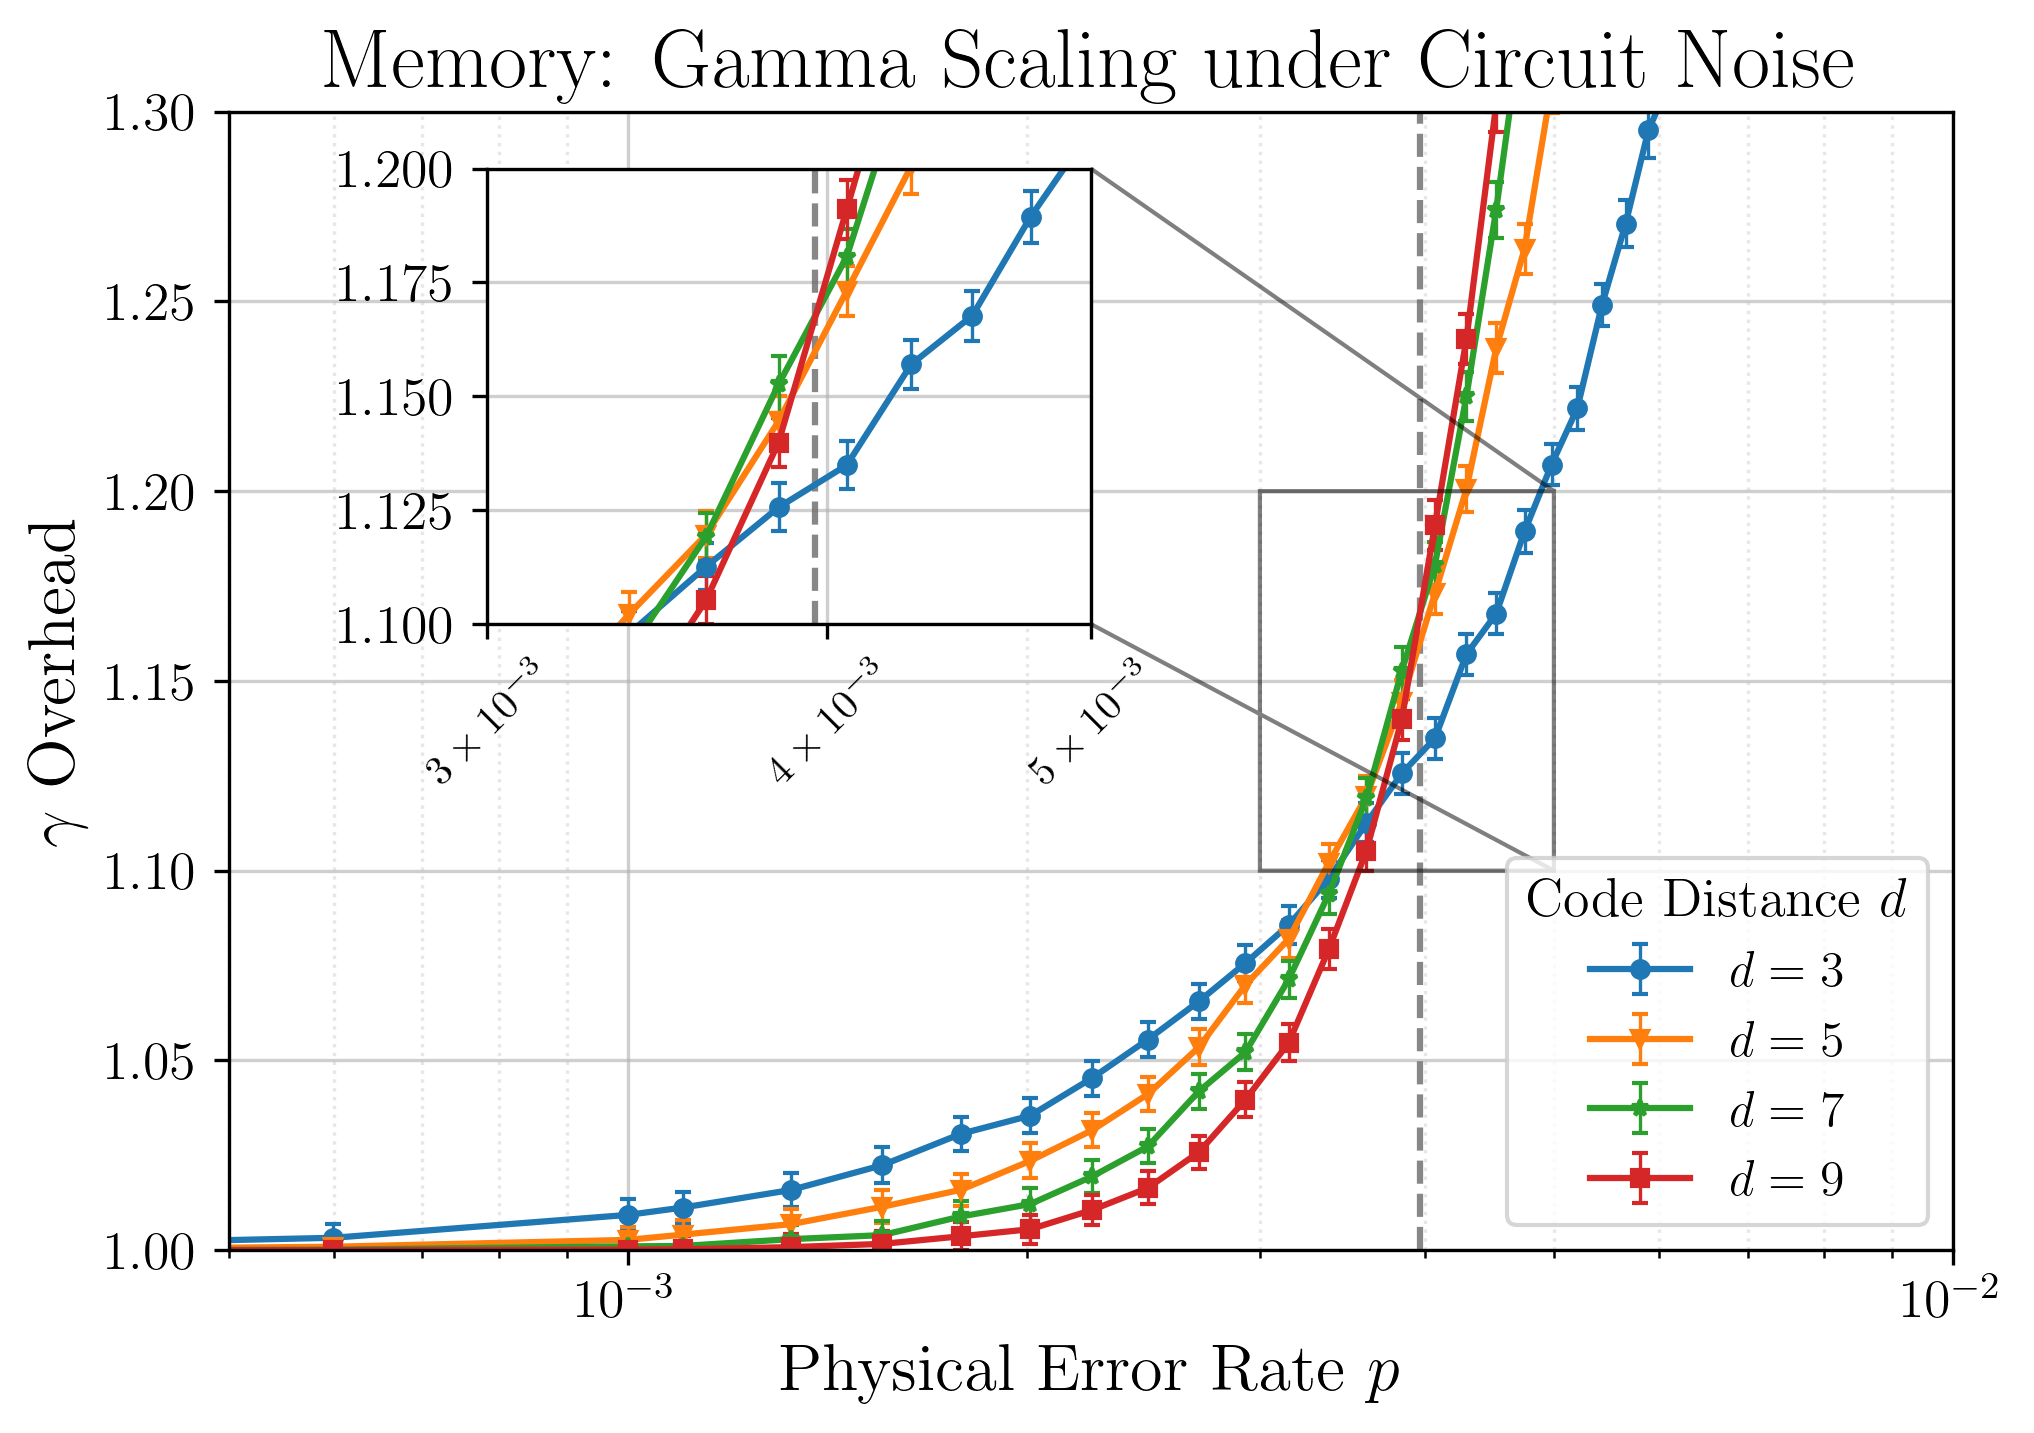

In [ ]:
# Define the threshold
THRESHOLD_P = 3.96e-3

# 1. Load the data
df = pd.read_csv('../data/gamma_memory.csv')

# Setup plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for distance, group in df.groupby('distance'):
    group_s = group.sort_values('physical_error_probability')
    p_vals   = group_s['physical_error_probability'].values
    g_vals   = group_s['gamma'].values
    yerr = np.array([sigma_m_lookup[distance].get(float(f"{p:.2e}"), np.nan) for p in p_vals])
    ax.errorbar(
        p_vals, g_vals,
        yerr=yerr,
        **DIST_STYLE[distance],
        markersize=4,
        capsize=2,
        elinewidth=0.8,
        label=rf"$d={distance}$",
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 1.3)
ax.set_xlim(5e-4, 1e-2)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(LogFormatterMathtext()) 
ax.set_title("Memory: Gamma Scaling under Circuit Noise", fontsize=20)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"$\gamma$ Overhead")
ax.grid(which='major', linestyle='-', alpha=0.6)
ax.grid(which='minor', linestyle=':', alpha=0.3)
ax.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)
ax.legend(title="Code Distance $d$", loc='lower right')

# Inset Plot for the Threshold Zoom
axins = ax.inset_axes([0.15, 0.55, 0.35, 0.4])

# Re-plot the data onto the inset axes
for distance, group in df.groupby('distance'):
    group_s = group.sort_values('physical_error_probability')
    p_vals   = group_s['physical_error_probability'].values
    g_vals   = group_s['gamma'].values
    yerr = np.array([sigma_m_lookup[distance].get(float(f"{p:.2e}"), np.nan) for p in p_vals])

    axins.errorbar(
        p_vals, g_vals,
        yerr=yerr,
        **DIST_STYLE[distance],
        markersize=4,
        capsize=2,
        elinewidth=0.8,
    )

# Formatting the inset
axins.set_xscale('log')
axins.set_xticks([3e-3, 4e-3, 5e-3])
axins.xaxis.set_major_formatter(FuncFormatter(sci_format))
axins.xaxis.set_minor_formatter(plt.NullFormatter())
axins.tick_params(axis='x', rotation=45, labelsize=10)
axins.set_xlim(3e-3, 5e-3)
axins.set_ylim(1.1, 1.2) 
axins.grid(which='major', linestyle='-', alpha=0.6)
axins.grid(which='minor', linestyle=':', alpha=0.3)
axins.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)
axins.set_xlabel('')
axins.set_ylabel('')
ax.indicate_inset_zoom(axins, edgecolor="black")

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("../plots/gamma_memory_d3579_error_bars.pdf", bbox_inches='tight')

plt.show()

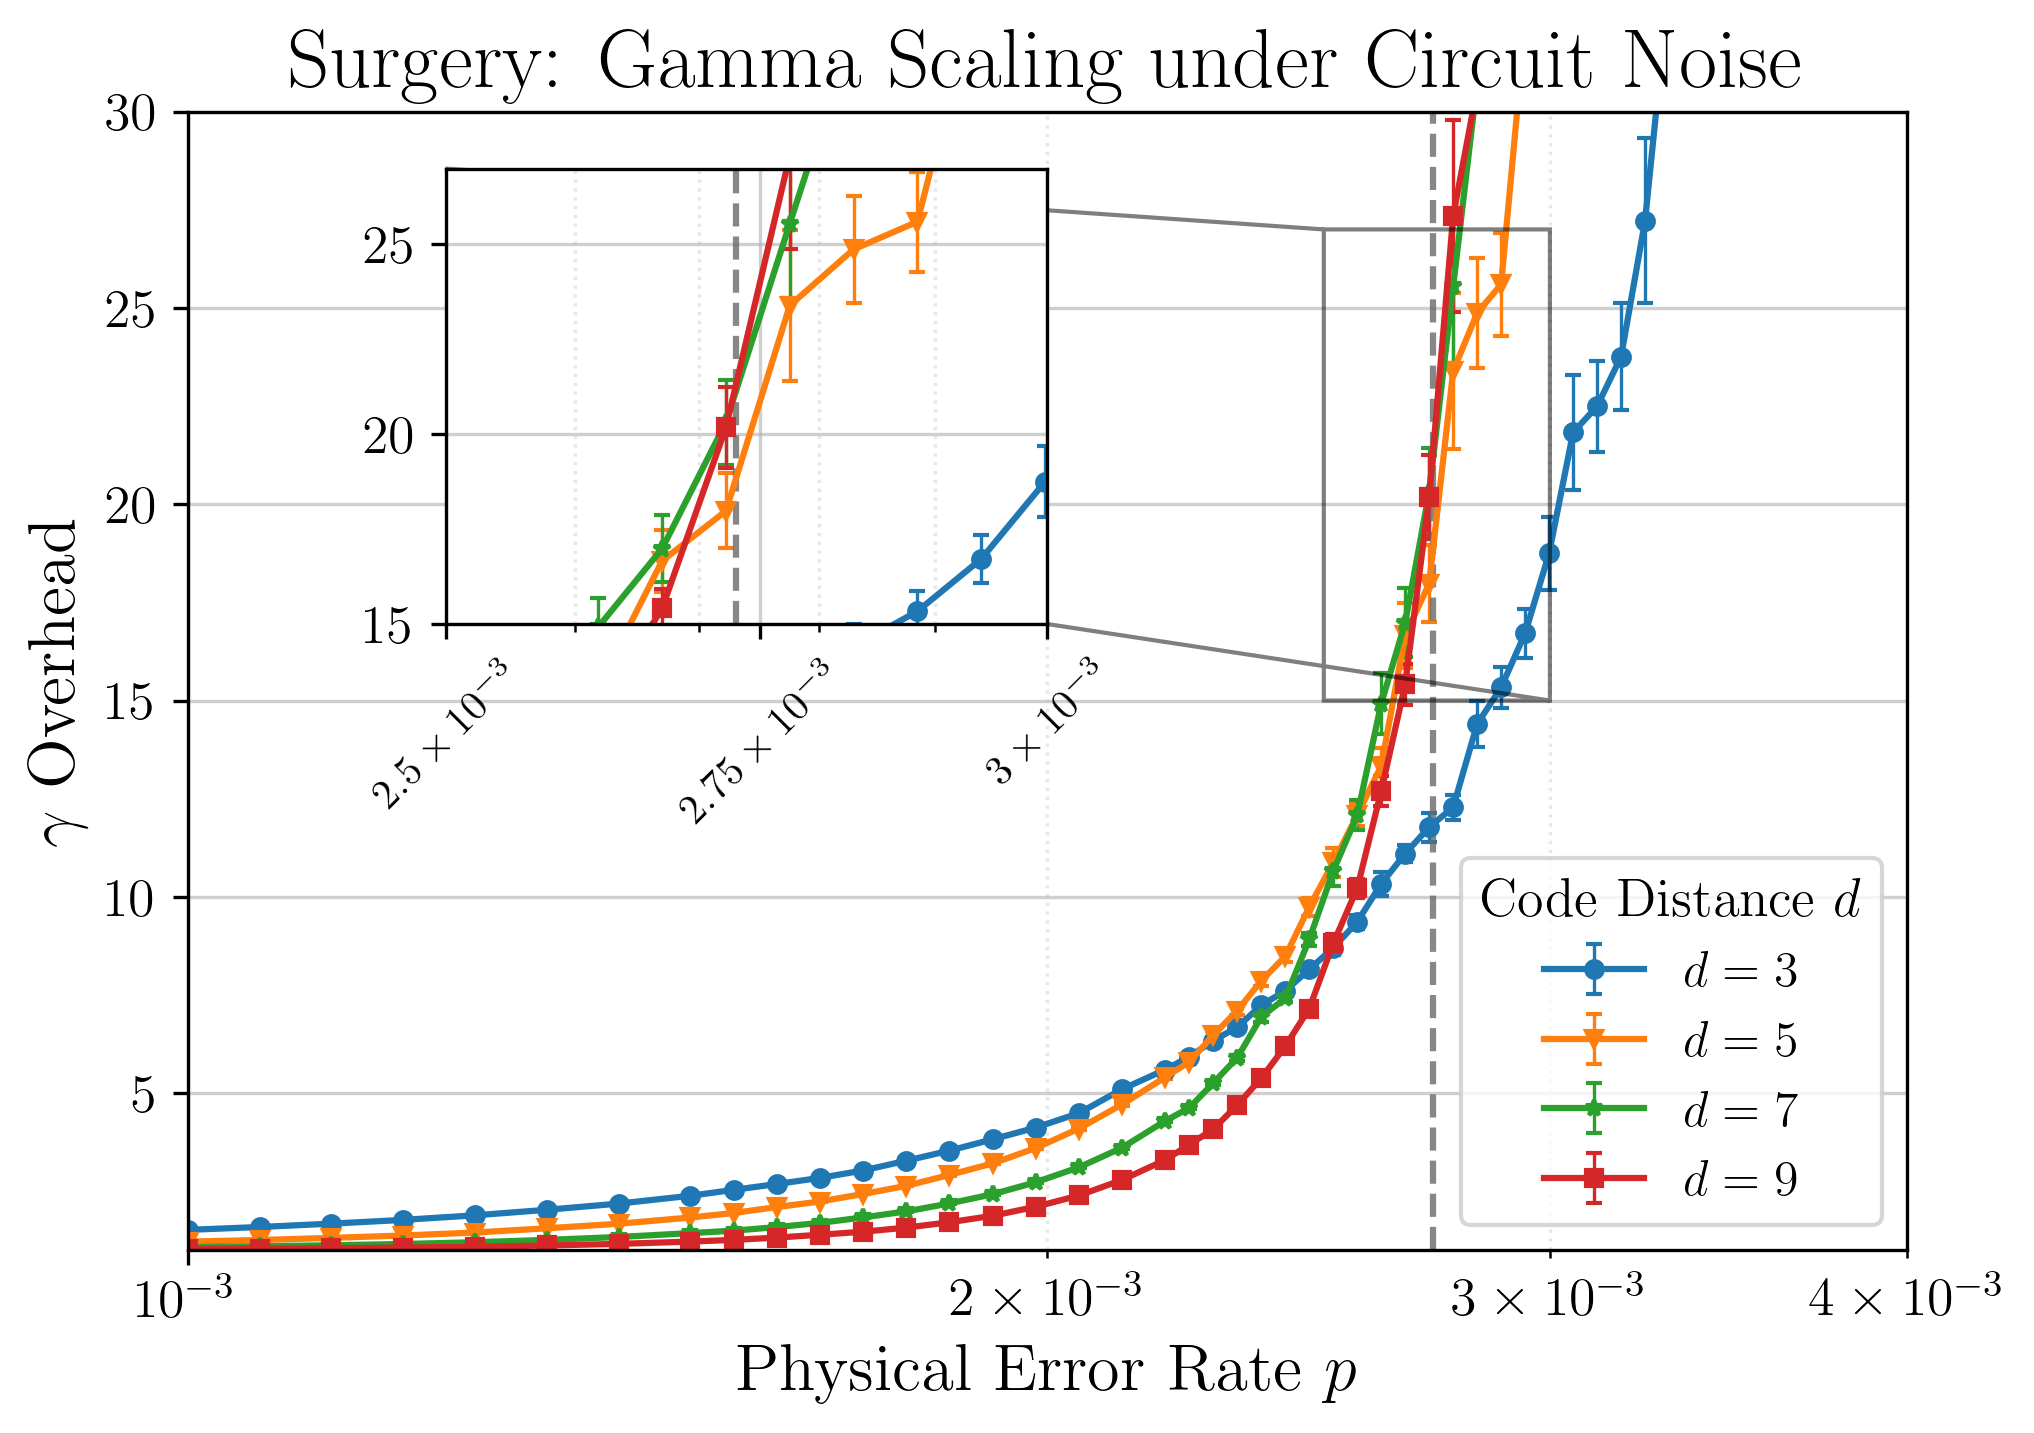

In [ ]:
# Define the threshold
THRESHOLD_P = 2.73e-3

# 1. Load the data
df = pd.read_csv('../data/gamma_surgery.csv')

# Setup Plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for distance, group in df.groupby('distance'):
    group_s = group.sort_values('physical_error_probability')
    p_vals   = group_s['physical_error_probability'].values
    g_vals   = group_s['gamma'].values
    yerr = np.array([sigma_s_lookup[distance].get(float(f"{p:.2e}"), np.nan) for p in p_vals])

    # Filter: hide error bars that extend outside the plot or exceed 30% relative uncertainty
    yerr_display = yerr.copy()
    too_large = (
        ~np.isfinite(yerr) |
        (g_vals + yerr > 30.0) |
        (yerr / np.where(g_vals > 0, g_vals, np.inf) > 0.30)
    )
    yerr_display[too_large] = np.nan

    ax.errorbar(
        p_vals, g_vals,
        yerr=yerr_display,
        **DIST_STYLE[distance],
        markersize=4,
        capsize=2,
        elinewidth=0.8,
        label=rf"$d={distance}$",
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 30.0)
ax.set_xlim(1e-3, 4e-3)
ax.set_xscale('log') 
ax.xaxis.set_major_formatter(LogFormatterMathtext())
ax.set_title("Surgery: Gamma Scaling under Circuit Noise", fontsize=20)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"$\gamma$ Overhead")
ax.grid(which='major', linestyle='-', alpha=0.6)
ax.grid(which='minor', linestyle=':', alpha=0.3)
ax.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)
ax.legend(title="Code Distance $d$", loc='lower right')

# 4. Inset Plot for the Threshold Zoom
axins = ax.inset_axes([0.15, 0.55, 0.35, 0.4])

# Re-plot the data onto the inset axes
for distance, group in df.groupby('distance'):
    group_s = group.sort_values('physical_error_probability')
    p_vals   = group_s['physical_error_probability'].values
    g_vals   = group_s['gamma'].values
    yerr = np.array([sigma_s_lookup[distance].get(float(f"{p:.2e}"), np.nan) for p in p_vals])

    # Filter: hide error bars that extend outside the plot or exceed 30% relative uncertainty
    yerr_display = yerr.copy()
    too_large = (
        ~np.isfinite(yerr) |
        (g_vals + yerr > 30.0) |
        (yerr / np.where(g_vals > 0, g_vals, np.inf) > 0.30)
    )
    yerr_display[too_large] = np.nan

    axins.errorbar(
        p_vals, g_vals,
        yerr=yerr_display,
        **DIST_STYLE[distance],
        markersize=4,
        capsize=2,
        elinewidth=0.8,
    )

# Formatting the inset
axins.set_xscale('log')
axins.set_xlim(2.5e-3, 3e-3)
axins.set_ylim(15.0, 27.0) 
axins.set_xticks([2.5e-3, 2.75e-3, 3.0e-3])
axins.xaxis.set_major_formatter(FuncFormatter(sci_format))
axins.xaxis.set_minor_formatter(plt.NullFormatter())
axins.tick_params(axis='x', rotation=45, labelsize=10)
axins.grid(which='major', linestyle='-', alpha=0.6)
axins.grid(which='minor', linestyle=':', alpha=0.3)
axins.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)
axins.set_xlabel('')
axins.set_ylabel('')
ax.indicate_inset_zoom(axins, edgecolor="black")

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("../plots/gamma_surgery_d3579_error_bars.pdf", bbox_inches='tight')

plt.show()

In [ ]:
# Define functions for calculation of Qubits Counts
def qubits_patch(d):
    return (2*(d**2) - 1)

def qubits_surgery_addtional(d):
    return ((d - 1) / 2) + 2

In [ ]:
# Getting all Qubit Budgets for Surgery
for d in [3,5,7,9]:

    complete_qubits = (3 * qubits_patch(d)) + (qubits_surgery_addtional(d)) - ((d-1) / 2)

    print(f"Distance {d} needs {complete_qubits} qubits for the surgery approach")

Distance 3 needs 53.0 qubits for the surgery approach
Distance 5 needs 149.0 qubits for the surgery approach
Distance 7 needs 293.0 qubits for the surgery approach
Distance 9 needs 485.0 qubits for the surgery approach


In [ ]:
qubits_patch(7)

97